In [2]:
!pip install librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ----------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import librosa

audio, sr = librosa.load(r"C:\Users\Shraddha\Downloads\viralaudio-descent-whoosh-long-cinematic-sound-effect-405921.mp3")

print("Sampling rate:", sr)

Sampling rate: 22050


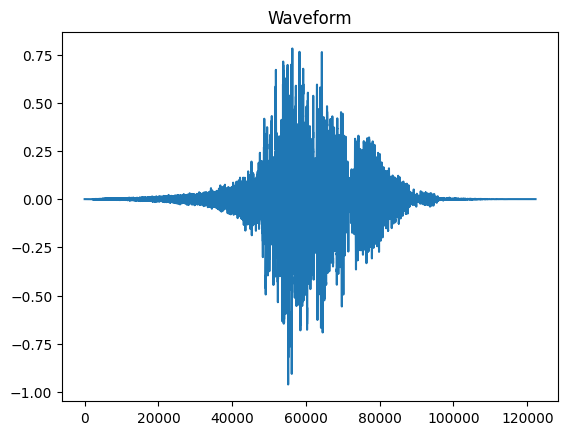

In [5]:
import librosa
import matplotlib.pyplot as plt

audio, sr = librosa.load(r"C:\Users\Shraddha\Downloads\viralaudio-descent-whoosh-long-cinematic-sound-effect-405921.mp3")

plt.plot(audio)
plt.title("Waveform")
plt.show()

C:\Users\Shraddha\AppData\Local\Temp\ipykernel_28388\3480401847.py:9: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  librosa.display.specshow(librosa.amplitude_to_db(spec))


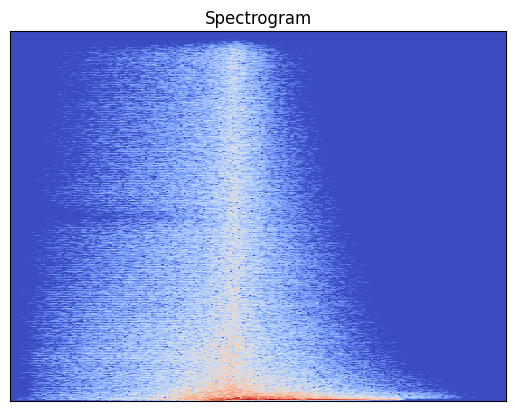

In [6]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

audio, sr = librosa.load(r"C:\Users\Shraddha\Downloads\viralaudio-descent-whoosh-long-cinematic-sound-effect-405921.mp3")

spec = librosa.stft(audio)

librosa.display.specshow(librosa.amplitude_to_db(spec))
plt.title("Spectrogram")
plt.show()

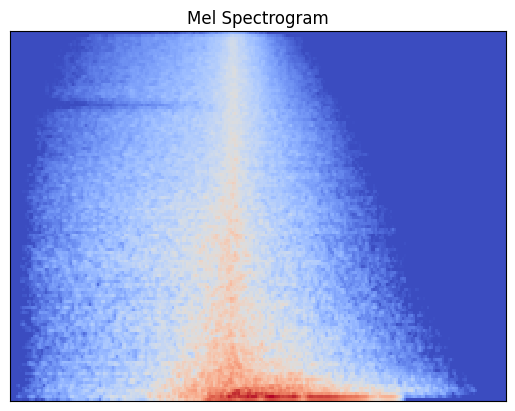

In [7]:
mel = librosa.feature.melspectrogram(y=audio, sr=sr)

librosa.display.specshow(librosa.power_to_db(mel))
plt.title("Mel Spectrogram")
plt.show()

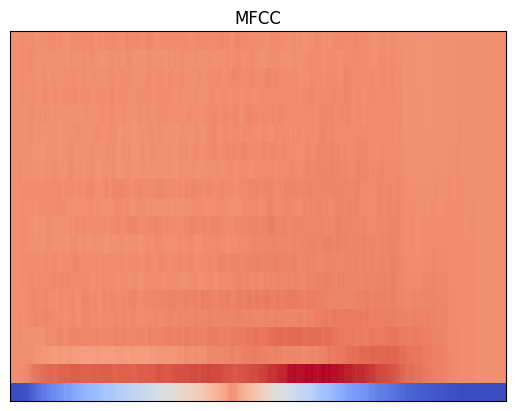

In [8]:
mfcc = librosa.feature.mfcc(y=audio, sr=sr)

librosa.display.specshow(mfcc)
plt.title("MFCC")
plt.show()

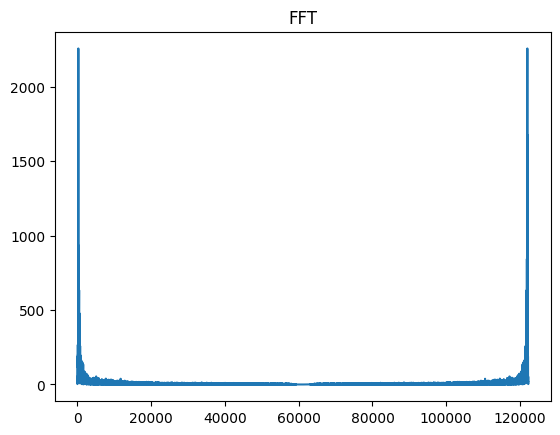

In [9]:
import numpy as np

fft = np.fft.fft(audio)

plt.plot(abs(fft))
plt.title("FFT")
plt.show()

In [3]:
#duration of audio

duration = librosa.get_duration(y=audio,sr=sr)
print(duration)

5.544036281179138


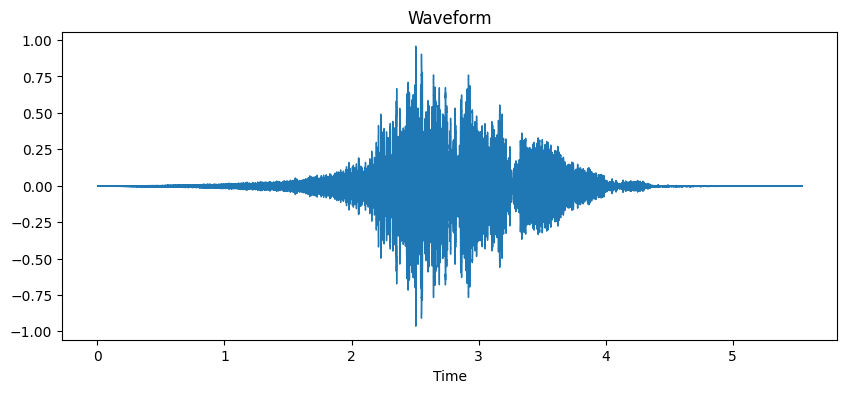

In [6]:
#Waveform visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
librosa.display.waveshow(audio,sr=sr)
plt.title("Waveform")
plt.show()

In [8]:
#Resampling
'''
Sampling rate = per second samples
Common values:

16000 → speech
22050 → default librosa
44100 → music
'''
audio_resampled=librosa.resample(audio,orig_sr=sr,target_sr=16000)

In [10]:
#Convert Stereo to Mono

audio, sr = librosa.load(r"C:\Users\Shraddha\Downloads\viralaudio-descent-whoosh-long-cinematic-sound-effect-405921.mp3", mono=True)
print(audio.shape)

(122246,)


In [11]:
#Convert Mono to Stereo

audio, sr = librosa.load(r"C:\Users\Shraddha\Downloads\viralaudio-descent-whoosh-long-cinematic-sound-effect-405921.mp3", mono=False)
print(audio.shape)

(2, 122246)


In [15]:
#Removing the silence part of audio
audio_trimmed, index = librosa.effects.trim(audio)

print(index)

[  2048 110592]


In [16]:
print(len(audio))
print(len(audio_trimmed))

2
2


In [17]:
audio_trimmed, _ = librosa.effects.trim(audio, top_db=20)

#top_db decides kitna silence remove krna h

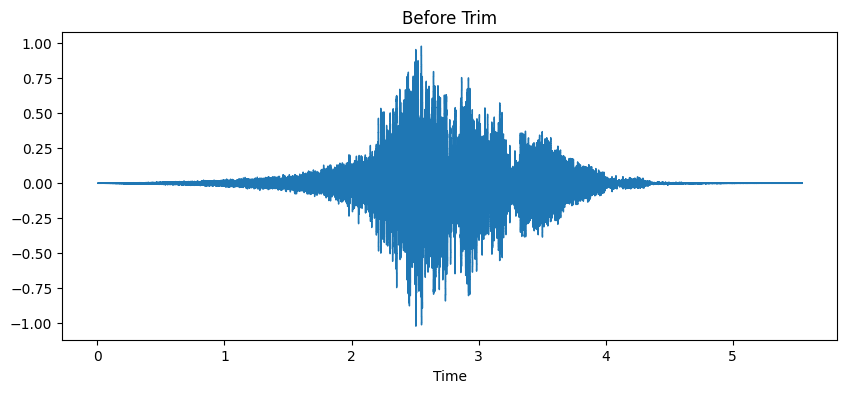

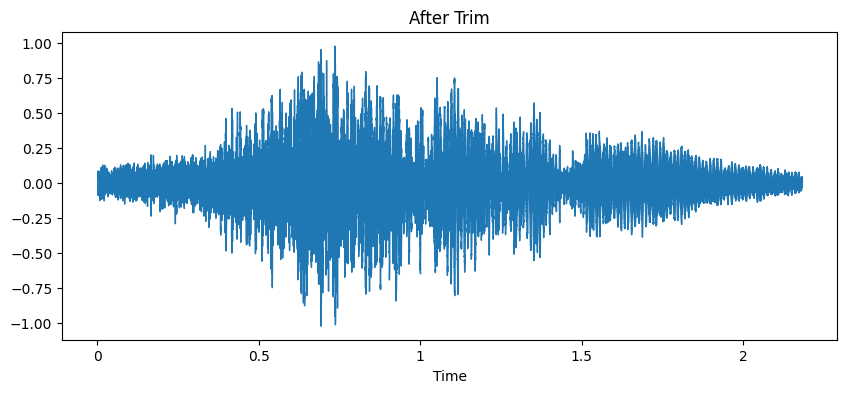

In [18]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10,4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Before Trim")

plt.figure(figsize=(10,4))
librosa.display.waveshow(audio_trimmed, sr=sr)
plt.title("After Trim")

plt.show()

In [20]:
#Normalize audio mean audio ki volume ko consistent range me scale krna( usually -1 se +1) mean audio na bht loud ho na bht slow
audio_norm = librosa.util.normalize(audio)

In [21]:
print(audio.min(), audio.max())
print(audio_norm.min(), audio_norm.max())

-1.0186034 0.8887726
-1.0 1.0


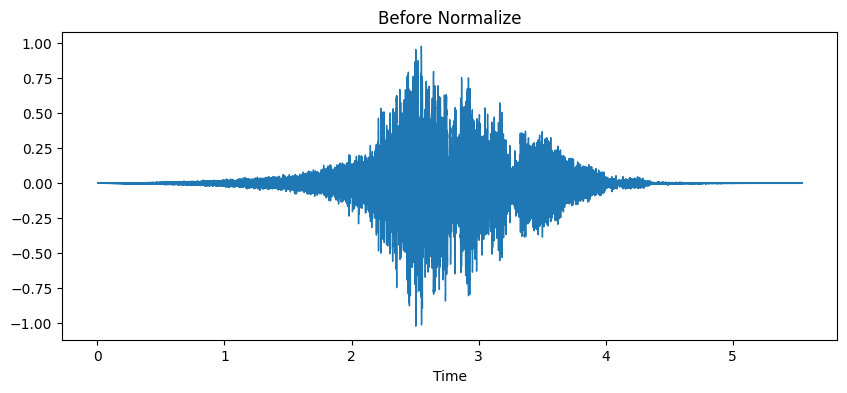

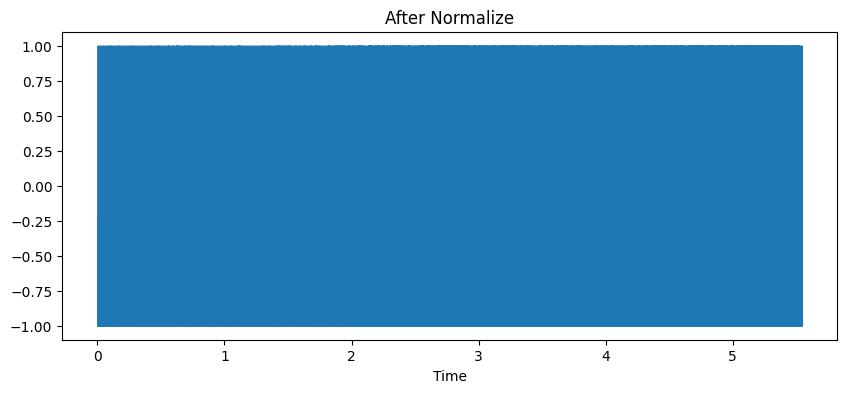

In [22]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10,4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Before Normalize")

plt.figure(figsize=(10,4))
librosa.display.waveshow(audio_norm, sr=sr)
plt.title("After Normalize")

plt.show()

In [23]:
#Short-Time Fourier Transform
#Time domain to frequency domain
stft = librosa.stft(audio)

In [25]:
#magnitude
import numpy as np
spectrogram = np.abs(stft)

In [27]:
audio, sr = librosa.load(r"C:\Users\Shraddha\Downloads\viralaudio-descent-whoosh-long-cinematic-sound-effect-405921.mp3", mono=True)

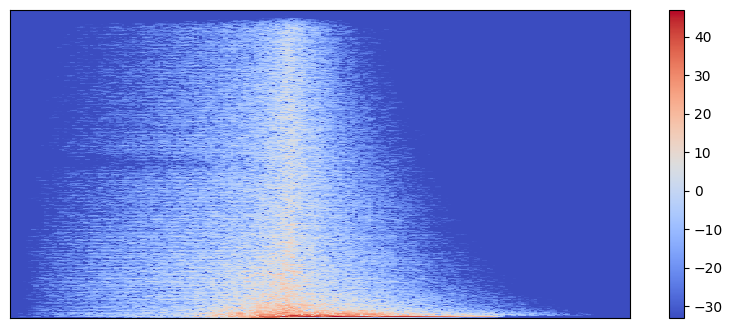

In [28]:
stft = librosa.stft(audio)
spectrogram = np.abs(stft)

plt.figure(figsize=(10,4))
librosa.display.specshow(librosa.amplitude_to_db(spectrogram), sr=sr)
plt.colorbar()
plt.show()

In [29]:
#Mel Spectrogram

mel = librosa.feature.melspectrogram(y=audio,sr=sr)

In [30]:
mel_db = librosa.power_to_db(mel)

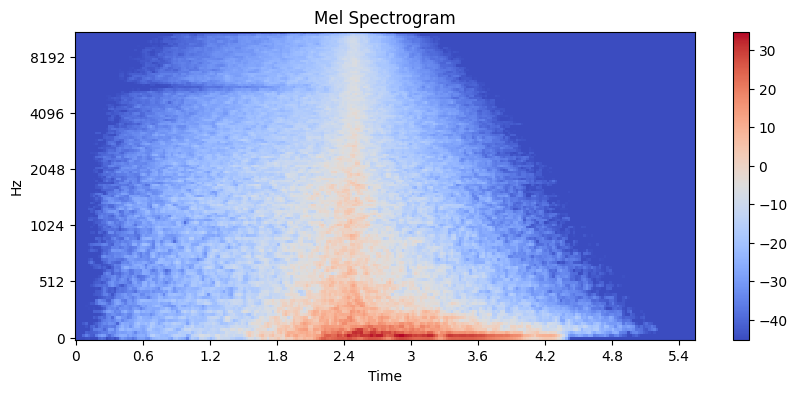

In [32]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

In [34]:
'''
important parameters
n_mels: Number of mel bands, usually 40: small models, 80: speech models, 128: deep learning
hop_length: Controls time resolution
n_fft: frequency resolution
'''

'\nimportant parameters\nn_mels: Number of mel bands, usually 40: small models, 80: speech models, 128: deep learning\nhop_length: Controls time resolution\nn_fft: frequency resolution\n'

In [36]:
print(mel_db.shape)  #128 mel bands, 239 time frames

(128, 239)


In [37]:
#MFCC= Mel frequency Cepstral Coefficients
mfcc = librosa.feature.mfcc(y=audio,sr=sr,n_mfcc=13)

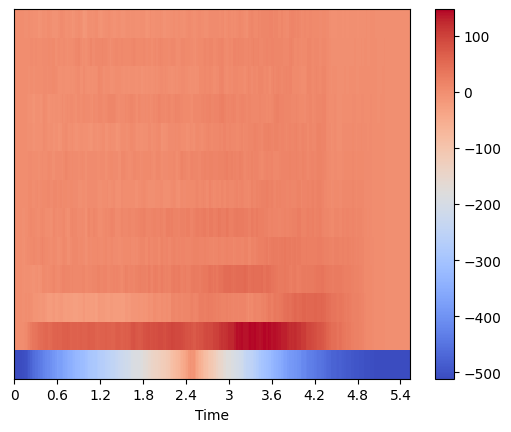

In [38]:
librosa.display.specshow(mfcc, sr=sr, x_axis='time')
plt.colorbar()
plt.show()

In [44]:
#MFCC: Mel Frequency Cepstral Coefficients
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

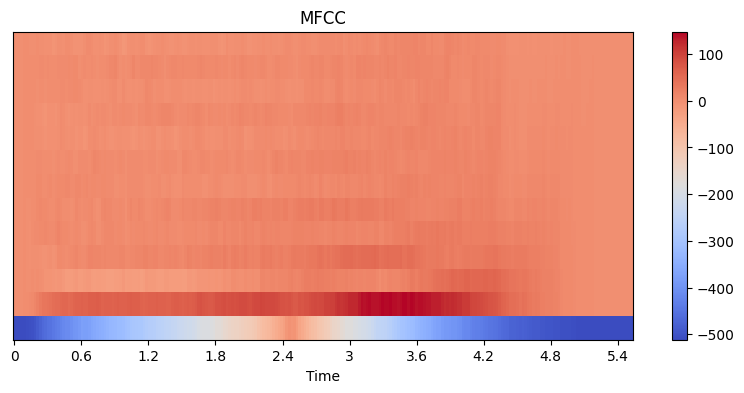

In [45]:
plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, sr=sr, x_axis='time')
plt.colorbar()
plt.title("MFCC")
plt.show()

In [46]:
print(mfcc.shape) #13 coefficients, 200 time frames
'''
13 coefficients bcz speech recognition me usually 13 MFCC use hote h bcz 
- enough speech info capture ho jaata h
- computational low rehta h
- standard practice

Parameters:
- n_mfcc 13: speech, 20: emotional detection, 40: deep learning
'''

(13, 239)


'\n13 coefficients bcz speech recognition me usually 13 MFCC use hote h bcz \n- enough speech info capture ho jaata h\n- computational low rehta h\n- standard practice\n\nParameters:\n- n_mfcc 13: speech, 20: emotional detection, 40: deep learning\n'

In [47]:
#Chroma Features
chroma = librosa.feature.chroma_stft(y=audio,sr=sr)

In [49]:
'''
Chroma Features audio ka pitch-based representation hota h jo music analysis me  use hota h
Ye 12 pitch classes (C,C#,D,D#,...B) ko represent krta h
basically chroma=konsa musical note(pitch class) active h
'''

'\nChroma Features audio ka pitch-based representation hota h jo music analysis me  use hota h\nYe 12 pitch classes (C,C#,D,D#,...B) ko represent krta h\nbasically chroma=konsa musical note(pitch class) active h\n'

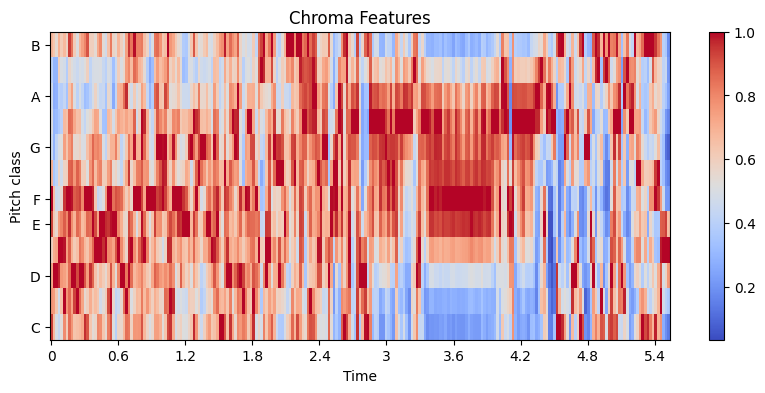

In [50]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    chroma,
    x_axis='time',
    y_axis='chroma',
    cmap='coolwarm'
)
plt.colorbar()
plt.title("Chroma Features")
plt.show()

In [52]:
print(chroma.shape) #12 pitch classes

(12, 239)


In [53]:
#Zero Crossing Rate: Signal kitni baar zero cross krta h
zcr = librosa.feature.zero_crossing_rate(audio)

In [54]:
print(zcr.shape)

(1, 239)


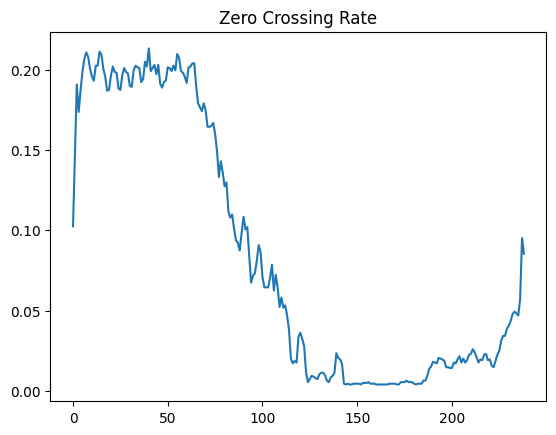

In [55]:
import matplotlib.pyplot as plt

plt.plot(zcr[0])
plt.title("Zero Crossing Rate")
plt.show()

In [58]:
#Spectral centroid: Brightness of sound basically freq k center of mass
# centroid = sum(frequency*magnitude)/sum(magnitude)
centroid = librosa.feature.spectral_centroid(y=audio,sr=sr)

In [59]:
print(centroid.shape)

(1, 239)


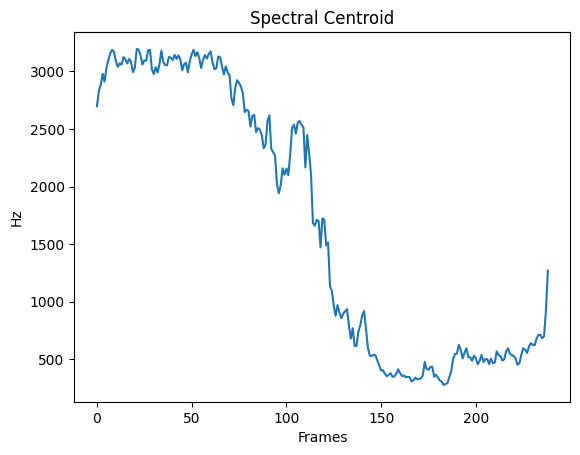

In [60]:
import matplotlib.pyplot as plt

plt.plot(centroid[0])
plt.title("Spectral Centroid")
plt.xlabel("Frames")
plt.ylabel("Hz")
plt.show()

In [62]:
#Spectral Bandwidth: ye btata h ki freq energy kitni spread hui h around the spectral centroid
#basically spectral bandwidth=sound kitna wide yaa spread h
#Bandwidth basically centroid se distance measure karta hai:
#bandwidth = sqrt( sum((freq - centroid)^2 * magnitude) )
bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)

In [63]:
print(bandwidth.shape)

(1, 239)


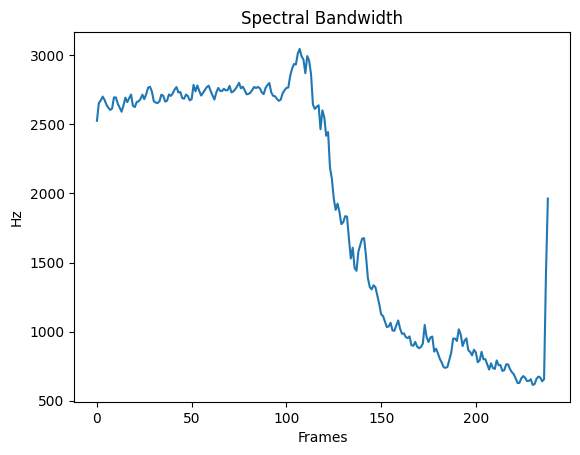

In [64]:
import matplotlib.pyplot as plt

plt.plot(bandwidth[0])
plt.title("Spectral Bandwidth")
plt.xlabel("Frames")
plt.ylabel("Hz")
plt.show()

In [65]:
'''
-Interpretation

Low Bandwidth
single tone
pure sound
less variation

- High Bandwidth

noisy sound
complex signal
many frequencies
'''

'\n-Interpretation\n\nLow Bandwidth\nsingle tone\npure sound\nless variation\n\n- High Bandwidth\n\nnoisy sound\ncomplex signal\nmany frequencies\n'

In [67]:
#Spectral rolloff
'''
spectral rolloff btata h ki total energy k kitna percent lower frequencies me h, simple words me: wo frequency jahan tk 85% energy accumulate ho jati h
jaha 85% energy complete ho jaati h-wahi rolloff frequency
'''
rolloff = librosa.feature.spectral_rolloff(y=audio,sr=sr)

In [68]:
#low rolloff: energy mostly low frquencies me
#high rolloff: energy high frequencies me bhi spread h

In [70]:
print(rolloff.shape) #1 feature

(1, 239)


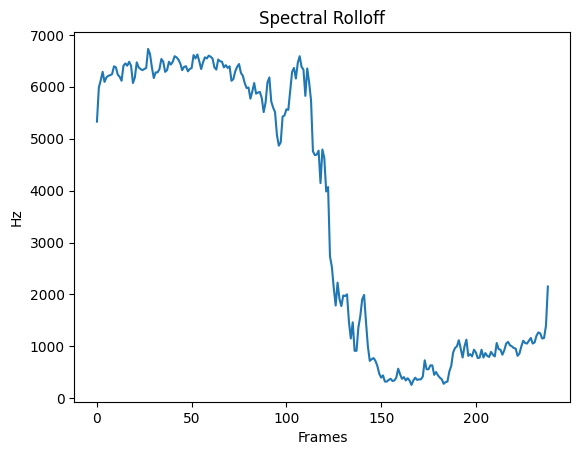

In [71]:
plt.plot(rolloff[0])
plt.title("Spectral Rolloff")
plt.xlabel("Frames")
plt.ylabel("Hz")
plt.show()

In [73]:
'''
Common values:

0.85 → standard
0.95 → more strict
0.75 → less strict

Low Rolloff
energy low freq me
smooth sound
bass heavy
High Rolloff
high freq energy
noisy sound
sharp sound
'''

'\nCommon values:\n\n0.85 → standard\n0.95 → more strict\n0.75 → less strict\n\nLow Rolloff\nenergy low freq me\nsmooth sound\nbass heavy\nHigh Rolloff\nhigh freq energy\nnoisy sound\nsharp sound\n'

In [78]:
#Tempo detection
'''
Tempo ka mtlb hota h music yaa audio ki speed-yani beats per minute(BPM), basically
 tempo=audio kitna fast yaa slow h
 '''
tempo, beats = librosa.beat.beat_track(y=audio, sr=sr)
print(tempo)

[107.66601562]


In [79]:
beat_times = librosa.frames_to_time(beats, sr=sr)

print(beat_times[:5])

[0.65015873 1.20743764 1.71827664 2.27555556]


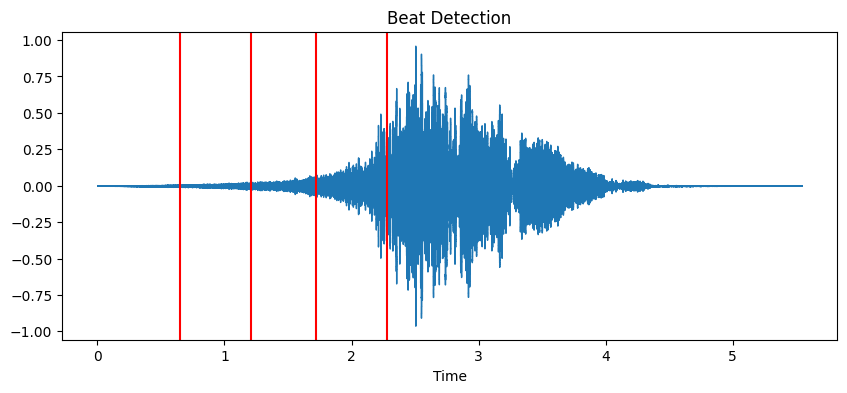

In [80]:
plt.figure(figsize=(10,4))
librosa.display.waveshow(audio, sr=sr)

for bt in beat_times:
    plt.axvline(bt, color='r')

plt.title("Beat Detection")
plt.show()

In [82]:
#Onset detection: Onset detection ka mtlb hota h audio me jb new sound start hota h toh us moment ko detect krna

onset_frames = librosa.onset.onset_detect(y=audio, sr=sr)

In [83]:
print(onset_frames[:10])

[11 13 20 27 31 39 45 52 57 63]


In [84]:
onset_times = librosa.frames_to_time(onset_frames, sr=sr)

print(onset_times[:5])

[0.2554195  0.30185941 0.46439909 0.62693878 0.71981859]


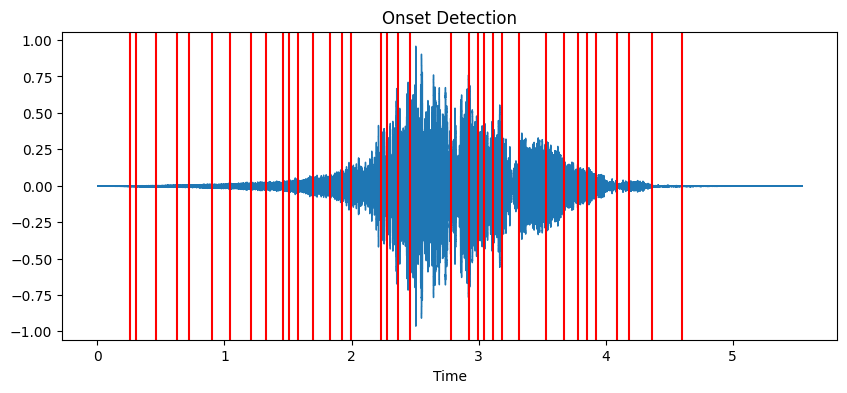

In [85]:
plt.figure(figsize=(10,4))
librosa.display.waveshow(audio, sr=sr)

for t in onset_times:
    plt.axvline(t, color='r')

plt.title("Onset Detection")
plt.show()

In [86]:
onset_env = librosa.onset.onset_strength(y=audio, sr=sr)  #onset strength: It tells how the strong is onset

In [88]:
#Harmonic vs Percussive Separation(HPSS):
'''
It splits the audio into two parts:
1. Harmonic: Continuous Sounds(melody,voice,violin)
2. Percussive: Short hit sounds(drums,clap,beats)
'''

'\nIt splits the audio into two parts:\n1. Harmonic: Continuous Sounds(melody,voice,violin)\n2. Percussive: Short hit sounds(drums,clap,beats)\n'

In [89]:
harmonic, percussive = librosa.effects.hpss(audio)

In [90]:
print(harmonic.shape)
print(percussive.shape)

(122246,)
(122246,)


In [91]:
import soundfile as sf

sf.write("harmonic.wav", harmonic, sr)
sf.write("percussive.wav", percussive, sr)

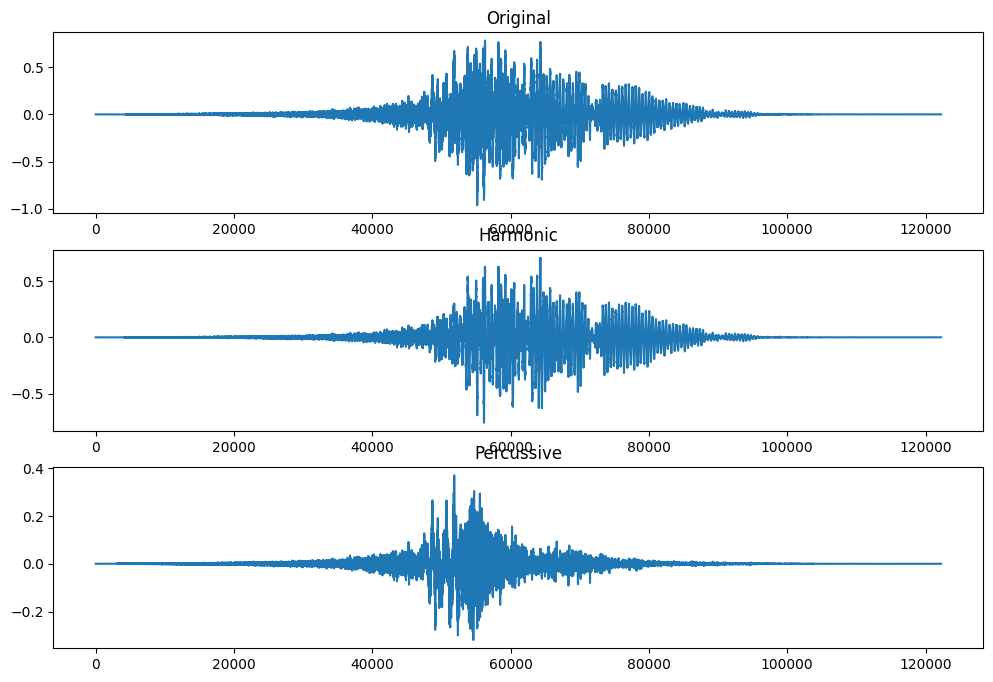

In [92]:
plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.title("Original")
plt.plot(audio)

plt.subplot(3,1,2)
plt.title("Harmonic")
plt.plot(harmonic)

plt.subplot(3,1,3)
plt.title("Percussive")
plt.plot(percussive)



In [95]:
#Pitch detection: Finding the fundamental frequency(F0) of audio basically sound kitna high yaa low h
pitches, magnitudes = librosa.piptrack(y=audio, sr=sr)  #pitches → frequency values  magnitudes → strength

In [96]:
print(pitches.shape)

(1025, 239)


In [98]:
pitch_values = []

for i in range(pitches.shape[1]):
    index = magnitudes[:, i].argmax()
    pitch_values.append(pitches[index, i])

print(pitch_values[:10])

[520.68396, 293.0482, 150.18358, 154.885, 151.45218, 1100.6498, 700.1969, 849.91943, 346.87463, 347.55048]


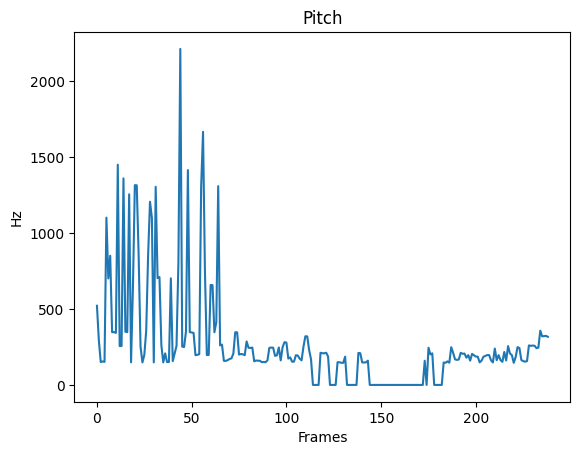

In [100]:
plt.plot(pitch_values)
plt.title("Pitch")
plt.ylabel("Hz")
plt.xlabel("Frames")
plt.show()

In [101]:
#Convert Frames to Time
times = librosa.frames_to_time(onset_frames, sr=sr)

In [102]:
#Feature Stacking for ML
mfcc = librosa.feature.mfcc(y=audio, sr=sr)
zcr = librosa.feature.zero_crossing_rate(audio)
spec_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)

features = np.vstack([mfcc, zcr, spec_centroid])

In [103]:
#Loading Example Audio
audio_path = librosa.ex('trumpet')
audio, sr = librosa.load(audio_path)

In [105]:
#Time Stretch: Changing the speed of audio without changing the pitch
slow = librosa.effects.time_stretch(audio, rate=0.8)

In [106]:
fast = librosa.effects.time_stretch(audio, rate=1.5)

In [107]:
sf.write("slow.wav", slow, sr)
sf.write("fast.wav", fast, sr)

In [108]:
print(len(audio))

117601


In [109]:
print(len(slow))

147001


In [110]:
print(len(fast))

78401


In [111]:
#Pitch Shift: Changing the pitch of audio without changing the duration
shifted = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)

In [112]:
high = librosa.effects.pitch_shift(audio, sr=sr, n_steps=4)

In [113]:
low = librosa.effects.pitch_shift(audio, sr=sr, n_steps=-4)

In [114]:
sf.write("high.wav", high, sr)
sf.write("low.wav", low, sr)

In [115]:
mfcc = librosa.feature.mfcc(y=audio, sr=sr)
zcr = librosa.feature.zero_crossing_rate(audio)
centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)

features = np.concatenate([
    np.mean(mfcc, axis=1),
    np.mean(zcr, axis=1),
    np.mean(centroid, axis=1)
])

print(features.shape)

(22,)
